In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [5]:
df= pd.read_csv("dataset.csv")
df.head()

/tmp/ipykernel_6978/2485654901.py:1: DtypeWarning: Columns (0: Kode POS, 1: wilayah, 2: tahun rakit, 3: DLR group, 4: tgl mohon) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv("dataset.csv")


,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Tgl Lahir,...,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,DLR group,tgl cetak,tgl mohon,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1992-03-03 0:00:00,...,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02-01-2019,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1991-04-27 0:00:00,...,3 jt up,6471,AT LOW,HN,18685000.0,NaN,NaN,NaN,02012019,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1982-01-04 0:00:00,...,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1997-06-26 0:00:00,...,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02012019,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1996-07-12 0:00:00,...,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,NaN,NaN,02-01-2019,6471-6400


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 319978 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         319964 non-null  str    
 1   Kelurahan           319962 non-null  str    
 2   Kecamatan           319963 non-null  str    
 3   Kode POS            319963 non-null  object 
 4   Cash/Credit         319963 non-null  float64
 5   Kode Dealer         319963 non-null  float64
 6   Finance Company     319889 non-null  str    
 7   Tenor               319942 non-null  str    
 8   Gender              319962 non-null  str    
 9   Tgl Lahir           319963 non-null  str    
 10  Agama               319963 non-null  str    
 11  Pekerjaan           319963 non-null  str    
 12  umur                319963 non-null  float64
 13  dp aktual           319234 non-null  str    
 14  cicilan             319276 non-null  str    
 15  warna               319963 non-null  str    


In [7]:
df.describe()

,Cash/Credit,Kode Dealer,umur,OTR,tgl cetak
count,319963.000000,319963.000000,319963.000000,3.199590e+05,1.322600e+04
mean,1.564146,29590.377194,94.346583,6.541080e+07,1.334797e+07
std,0.495869,44345.496360,134.293311,9.053097e+07,8.308178e+06
min,1.000000,733.000000,0.000000,0.000000e+00,1.042019e+06
25%,1.000000,10412.000000,28.000000,2.117000e+07,6.032019e+06
50%,2.000000,13115.000000,39.000000,2.361500e+07,1.210202e+07
75%,2.000000,16919.000000,53.000000,3.404000e+07,1.908202e+07
max,2.000000,168507.000000,1230.000000,9.301000e+08,3.112202e+07


In [8]:
df.isnull().sum()

Customer ID               14
Kelurahan                 16
Kecamatan                 15
Kode POS                  15
Cash/Credit               15
Kode Dealer               15
Finance Company           89
Tenor                     36
Gender                    16
Tgl Lahir                 15
Agama                     15
Pekerjaan                 15
umur                      15
dp aktual                744
cicilan                  702
warna                     15
dealer                    15
type series               15
range dp                  15
wilayah                   15
9 segment                 15
kode motor                54
OTR                       19
tahun rakit             9912
DLR group             258181
tgl cetak             306752
tgl mohon                 14
Kode Kota-Provinsi         0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2341)

In [10]:
df_drop=df.drop_duplicates()

In [11]:
df_drop.duplicated().sum()

np.int64(0)

In [12]:
df_drop.info()

<class 'pandas.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  str    
 1   Kelurahan           317634 non-null  str    
 2   Kecamatan           317635 non-null  str    
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317635 non-null  float64
 5   Kode Dealer         317635 non-null  float64
 6   Finance Company     317562 non-null  str    
 7   Tenor               317614 non-null  str    
 8   Gender              317634 non-null  str    
 9   Tgl Lahir           317635 non-null  str    
 10  Agama               317635 non-null  str    
 11  Pekerjaan           317635 non-null  str    
 12  umur                317635 non-null  float64
 13  dp aktual           316937 non-null  str    
 14  cicilan             316979 non-null  str    
 15  warna               317635 non-null  str    
 16  

In [13]:
df_drop=df_drop.drop(columns=["DLR group","tgl cetak","tgl mohon"])


In [14]:
df_drop.columns.to_list()

['Customer ID',
 'Kelurahan',
 'Kecamatan',
 'Kode POS',
 'Cash/Credit',
 'Kode Dealer',
 'Finance Company',
 'Tenor',
 'Gender',
 'Tgl Lahir',
 'Agama',
 'Pekerjaan',
 'umur',
 'dp aktual',
 'cicilan',
 'warna',
 'dealer',
 'type series',
 'range dp',
 'wilayah',
 '9 segment',
 'kode motor',
 'OTR',
 'tahun rakit',
 'Kode Kota-Provinsi']

In [15]:
num_cols=df_drop.select_dtypes(include=np.number).columns
num_cols

Index(['Cash/Credit', 'Kode Dealer', 'umur', 'OTR'], dtype='str')

In [16]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Tgl Lahir', 'Agama', 'Pekerjaan', 'dp aktual',
       'cicilan', 'warna', 'dealer', 'type series', 'range dp', 'wilayah',
       '9 segment', 'kode motor', 'tahun rakit', 'Kode Kota-Provinsi'],
      dtype='str')

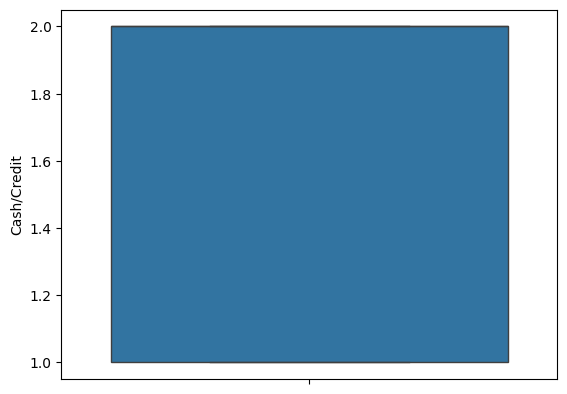

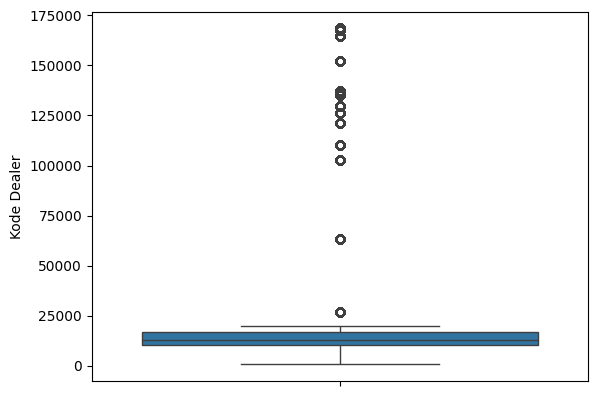

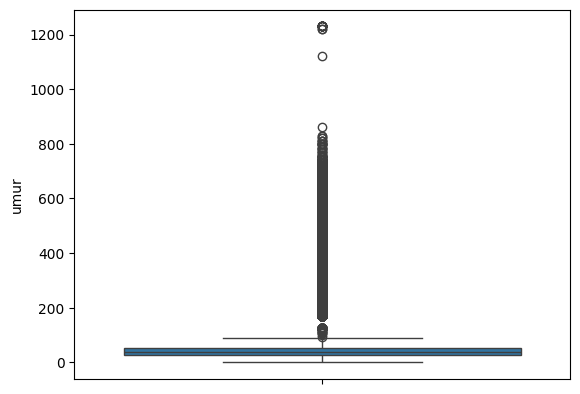

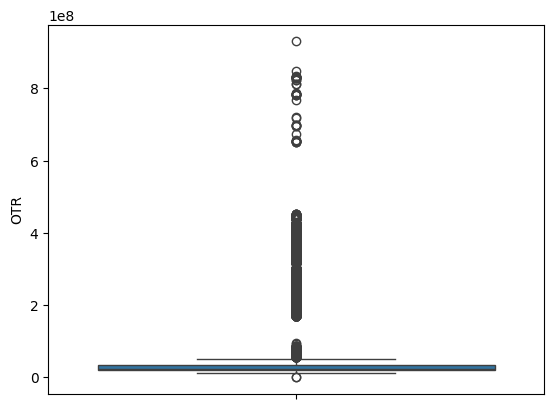

In [17]:
for cols in num_cols:
    sns.boxplot(df_drop[cols])
    plt.show()

In [18]:
for col in num_cols:
    Q1 = df_drop[col].quantile(0.25)
    Q3 = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_drop[(df_drop[col] < lower_bound) | (df_drop[col] > upper_bound)]
    print(f"Column: {col}")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)}\n")

Column: Cash/Credit
  Q1: 1.00, Q3: 2.00, IQR: 1.00
  Lower Bound: -0.50, Upper Bound: 3.50
  Number of outliers: 0

Column: Kode Dealer
  Q1: 10412.00, Q3: 16919.00, IQR: 6507.00
  Lower Bound: 651.50, Upper Bound: 26679.50
  Number of outliers: 51745

Column: umur
  Q1: 28.00, Q3: 53.00, IQR: 25.00
  Lower Bound: -9.50, Upper Bound: 90.50
  Number of outliers: 58060

Column: OTR
  Q1: 21160000.00, Q3: 34050000.00, IQR: 12890000.00
  Lower Bound: 1825000.00, Upper Bound: 53385000.00
  Number of outliers: 58272



### Outlier Treatment using IQR Capping

I will use the Interquartile Range (IQR) method to cap outliers in the numerical columns. This involves replacing values that fall below the `lower_bound` with the `lower_bound` itself, and values that fall above the `upper_bound` with the `upper_bound`.

In [19]:
for col in num_cols:
    Q1 = df_drop[col].quantile(0.25)
    Q3 = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df_drop[col] = np.where(df_drop[col] < lower_bound, lower_bound, df_drop[col])
    df_drop[col] = np.where(df_drop[col] > upper_bound, upper_bound, df_drop[col])
    print(f"Outliers in column '{col}' have been capped.")

Outliers in column 'Cash/Credit' have been capped.
Outliers in column 'Kode Dealer' have been capped.
Outliers in column 'umur' have been capped.
Outliers in column 'OTR' have been capped.


To verify that the outliers have been handled, let's re-run the outlier detection logic and visualize the boxplots again.

In [20]:
for col in num_cols:
    Q1 = df_drop[col].quantile(0.25)
    Q3 = df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_drop[(df_drop[col] < lower_bound) | (df_drop[col] > upper_bound)]
    print(f"Column: {col} (After capping)")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers)}\n")

Column: Cash/Credit (After capping)
  Q1: 1.00, Q3: 2.00, IQR: 1.00
  Lower Bound: -0.50, Upper Bound: 3.50
  Number of outliers: 0

Column: Kode Dealer (After capping)
  Q1: 10412.00, Q3: 16919.00, IQR: 6507.00
  Lower Bound: 651.50, Upper Bound: 26679.50
  Number of outliers: 0

Column: umur (After capping)
  Q1: 28.00, Q3: 53.00, IQR: 25.00
  Lower Bound: -9.50, Upper Bound: 90.50
  Number of outliers: 0

Column: OTR (After capping)
  Q1: 21160000.00, Q3: 34050000.00, IQR: 12890000.00
  Lower Bound: 1825000.00, Upper Bound: 53385000.00
  Number of outliers: 0



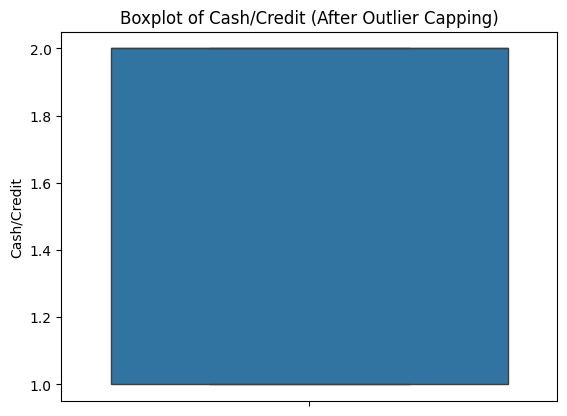

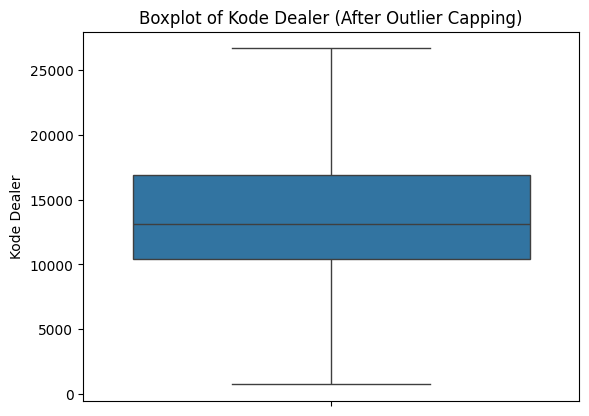

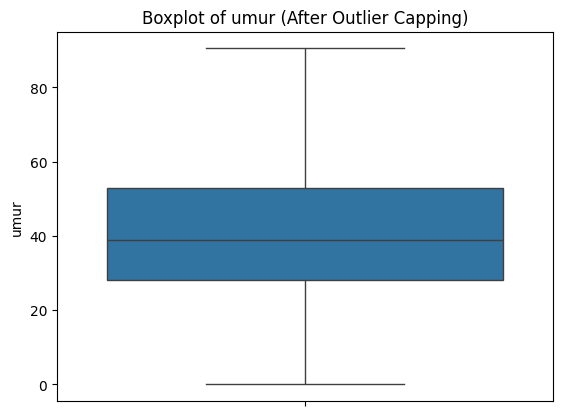

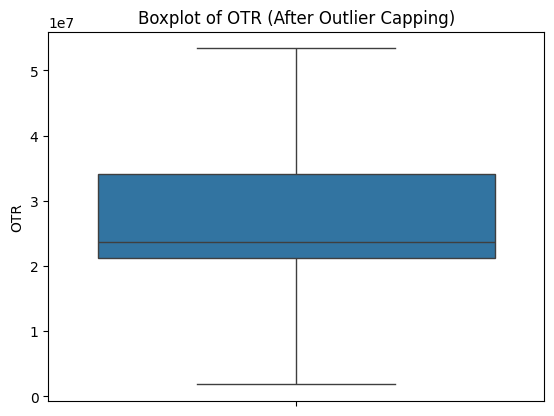

In [21]:
for cols in num_cols:
  sns.boxplot(df_drop[cols])
  plt.title(f'Boxplot of {cols} (After Outlier Capping)')
  plt.show()

In [22]:
df_drop=df_drop.drop(columns="Tgl Lahir")


In [23]:
df_drop.info()

<class 'pandas.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  str    
 1   Kelurahan           317634 non-null  str    
 2   Kecamatan           317635 non-null  str    
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317635 non-null  float64
 5   Kode Dealer         317635 non-null  float64
 6   Finance Company     317562 non-null  str    
 7   Tenor               317614 non-null  str    
 8   Gender              317634 non-null  str    
 9   Agama               317635 non-null  str    
 10  Pekerjaan           317635 non-null  str    
 11  umur                317635 non-null  float64
 12  dp aktual           316937 non-null  str    
 13  cicilan             316979 non-null  str    
 14  warna               317635 non-null  str    
 15  dealer              317635 non-null  str    
 16  

In [24]:
num_cols=df_drop.select_dtypes(include=np.number).columns
num_cols

Index(['Cash/Credit', 'Kode Dealer', 'umur', 'OTR'], dtype='str')

In [25]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Agama', 'Pekerjaan', 'dp aktual', 'cicilan',
       'warna', 'dealer', 'type series', 'range dp', 'wilayah', '9 segment',
       'kode motor', 'tahun rakit', 'Kode Kota-Provinsi'],
      dtype='str')

In [26]:
for cols in num_cols:
  df_drop[cols]=df_drop[cols].fillna(df_drop[cols].mean())
df_drop.isnull().sum()

Customer ID              1
Kelurahan                3
Kecamatan                2
Kode POS                 2
Cash/Credit              0
Kode Dealer              0
Finance Company         75
Tenor                   23
Gender                   3
Agama                    2
Pekerjaan                2
umur                     0
dp aktual              700
cicilan                658
warna                    2
dealer                   2
type series              2
range dp                 2
wilayah                  2
9 segment                2
kode motor              41
OTR                      0
tahun rakit           9860
Kode Kota-Provinsi       0
dtype: int64

In [27]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,3 jt up,6471,AT LOW,HN,18685000.0,NaN,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400


In [28]:
import pandas as pd
import re
import numpy as np

def clean_currency_column(col):
    """
    Bersihkan kolom finansial jadi float.

    Parameters:
        col : pd.Series
            Kolom bertipe object/string yang berisi nominal uang

    Returns:
        pd.Series float
    """
    def convert(x):
        if pd.isnull(x):
            return 0.0
        x = str(x).lower().replace('rp','').replace(' ','')
        # jika ada kata "juta", konversi ke angka
        if 'juta' in x:
            x = x.replace('juta','').replace(',', '.')
            try:
                return float(x) * 1_000_000
            except:
                return 0.0
        # ambil angka dan titik saja
        x = re.sub(r'[^0-9.]', '', x)
        if x == '':
            return 0.0
        try:
            return float(x)
        except:
            return 0.0

    return col.apply(convert)

In [29]:
from pandas.core.arrays.floating import Float64Dtype
for col in ['dp aktual','cicilan']:
    df_drop[col] = clean_currency_column(df[col])

In [30]:
df_drop.info()

<class 'pandas.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  str    
 1   Kelurahan           317634 non-null  str    
 2   Kecamatan           317635 non-null  str    
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317637 non-null  float64
 5   Kode Dealer         317637 non-null  float64
 6   Finance Company     317562 non-null  str    
 7   Tenor               317614 non-null  str    
 8   Gender              317634 non-null  str    
 9   Agama               317635 non-null  str    
 10  Pekerjaan           317635 non-null  str    
 11  umur                317637 non-null  float64
 12  dp aktual           317637 non-null  float64
 13  cicilan             317637 non-null  float64
 14  warna               317635 non-null  str    
 15  dealer              317635 non-null  str    
 16  

In [31]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,tahun rakit,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2 - 3 juta,6471,AT LOW,HN,18685000.0,NaN,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,3 jt up,6471,AT LOW,HN,18685000.0,NaN,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,kurang 1 juta,6471,AT MID,HR,20775000.0,NaN,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,krg 1 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2 - 3 jt,6471,AT MID,HR,20775000.0,NaN,6471-6400


In [32]:
def normalize_salary(x):
    if pd.isnull(x):
        return 'unknown'
    x = x.lower()
    if 'kurang' in x or 'krg' in x or '1 jt' in x and '-' not in x:
        return '<1 juta'
    elif '1 - 2' in x:
        return '1-2 juta'
    elif '2 - 3' in x:
        return '2-3 juta'
    elif '3' in x and 'up' in x:
        return '>3 juta'
    else:
        return 'other'

df_drop['range dp'] = df_drop['range dp'].apply(normalize_salary)

In [33]:
df_drop=df_drop.drop(columns="tahun rakit")

In [34]:
df_drop.head(10)

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,cicilan,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,Kode Kota-Provinsi
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,0.0,MC,Balikpapan,BREEZ SERIES,2-3 juta,6471,AT LOW,HN,18685000.0,6471-6400
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,20600000.0,MC,Balikpapan,BREEZ SERIES,>3 juta,6471,AT LOW,HN,18685000.0,6471-6400
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,0.0,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,0.0,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,12200000.0,MH,Balikpapan,SCOOTY SERIES,2-3 juta,6471,AT MID,HR,20775000.0,6471-6400
5,CUST-218443,Klandasan Ilir,Balikpapan Kota,76113,2.0,10411.0,1,2,2,1,...,13500000.0,MH,Balikpapan,SCOOTY SERIES,>3 juta,6471,AT MID,HR,20775000.0,6471-6400
6,CUST-199394,Klandasan Ilir,Balikpapan Kota,76113,1.0,12757.0,N,N,1,1,...,0.0,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400
7,CUST-200209,KLANDASAN ULU,BALIKPAPAN KOTA,76112,1.0,733.0,N,N,1,1,...,0.0,BK,Balikpapan,BREEZ SERIES,<1 juta,6471,AT LOW,HO,17975000.0,6471-6400
8,CUST-09898,TELAGA SARI,BALIKPAPAN KOTA,45261,1.0,733.0,N,N,1,1,...,0.0,BK,Balikpapan,VAREX 125 SERIES,<1 juta,6471,AT MID,HB,22495000.0,6471-6400
9,CUST-194316,DAMAI BAHAGIA,BALIKPAPAN SELATAN,76114,1.0,733.0,N,N,2,1,...,0.0,BK,Balikpapan,RYVO SERIES,<1 juta,6471,CUB LOW,GF,17460000.0,6471-6400


In [35]:
df_drop['range dp'].unique()

<StringArray>
['2-3 juta', '>3 juta', '<1 juta', '1-2 juta', 'unknown']
Length: 5, dtype: str

In [36]:
for i in num_cols:
  df_drop[i]=df_drop[i].fillna(df_drop[i].mean())
df_drop.info()

<class 'pandas.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Customer ID         317636 non-null  str    
 1   Kelurahan           317634 non-null  str    
 2   Kecamatan           317635 non-null  str    
 3   Kode POS            317635 non-null  object 
 4   Cash/Credit         317637 non-null  float64
 5   Kode Dealer         317637 non-null  float64
 6   Finance Company     317562 non-null  str    
 7   Tenor               317614 non-null  str    
 8   Gender              317634 non-null  str    
 9   Agama               317635 non-null  str    
 10  Pekerjaan           317635 non-null  str    
 11  umur                317637 non-null  float64
 12  dp aktual           317637 non-null  float64
 13  cicilan             317637 non-null  float64
 14  warna               317635 non-null  str    
 15  dealer              317635 non-null  str    
 16  

In [37]:
df_drop.isnull().sum()

Customer ID            1
Kelurahan              3
Kecamatan              2
Kode POS               2
Cash/Credit            0
Kode Dealer            0
Finance Company       75
Tenor                 23
Gender                 3
Agama                  2
Pekerjaan              2
umur                   0
dp aktual              0
cicilan                0
warna                  2
dealer                 2
type series            2
range dp               0
wilayah                2
9 segment              2
kode motor            41
OTR                    0
Kode Kota-Provinsi     0
dtype: int64

In [38]:
num_cols=df_drop.select_dtypes(include=np.number).columns
num_cols

Index(['Cash/Credit', 'Kode Dealer', 'umur', 'dp aktual', 'cicilan', 'OTR'], dtype='str')

In [39]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Agama', 'Pekerjaan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor',
       'Kode Kota-Provinsi'],
      dtype='str')

In [40]:
for cols in cat_cols:
  df_drop[cols]=df_drop[cols].fillna(df_drop[cols].mode()[0])
df_drop.isnull().sum()

Customer ID           0
Kelurahan             0
Kecamatan             0
Kode POS              0
Cash/Credit           0
Kode Dealer           0
Finance Company       0
Tenor                 0
Gender                0
Agama                 0
Pekerjaan             0
umur                  0
dp aktual             0
cicilan               0
warna                 0
dealer                0
type series           0
range dp              0
wilayah               0
9 segment             0
kode motor            0
OTR                   0
Kode Kota-Provinsi    0
dtype: int64

In [41]:
df_drop.columns

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Cash/Credit',
       'Kode Dealer', 'Finance Company', 'Tenor', 'Gender', 'Agama',
       'Pekerjaan', 'umur', 'dp aktual', 'cicilan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor', 'OTR',
       'Kode Kota-Provinsi'],
      dtype='str')

In [42]:
# hitung jumlah transaksi per customer
df_drop['repeat_flag'] = df_drop.groupby('Customer ID')['Customer ID'].transform('count').gt(1).astype(int)

In [43]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,Kode Kota-Provinsi,repeat_flag
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2-3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,>3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,N,N,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2-3 juta,6471,AT MID,HR,20775000.0,6471-6400,0


In [44]:
cat_cols

Index(['Customer ID', 'Kelurahan', 'Kecamatan', 'Kode POS', 'Finance Company',
       'Tenor', 'Gender', 'Agama', 'Pekerjaan', 'warna', 'dealer',
       'type series', 'range dp', 'wilayah', '9 segment', 'kode motor',
       'Kode Kota-Provinsi'],
      dtype='str')

In [45]:
df_drop.value_counts('Finance Company')

Finance Company
N     137181
1     134645
2      13823
4       9706
11      7109
5       6379
3       3318
9       2052
13      1629
36      1110
26       677
37         3
6          2
12         1
16         1
25         1
Name: count, dtype: int64

In [46]:
df_drop['Tenor'] = df_drop['Tenor'].replace('N',0)
df_drop['Finance Company'] = df_drop['Finance Company'].replace('N','unknown')

In [47]:
df_drop.head()

,Customer ID,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,Gender,Agama,...,warna,dealer,type series,range dp,wilayah,9 segment,kode motor,OTR,Kode Kota-Provinsi,repeat_flag
0,CUST-159769,Baru Ilir,Balikpapan Barat,76131,2.0,12756.0,4,3,2,1,...,MC,Balikpapan,BREEZ SERIES,2-3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
1,CUST-164551,BARU TENGAH,BALIKPAPAN BARAT,76132,2.0,733.0,1,1,2,1,...,MC,Balikpapan,BREEZ SERIES,>3 juta,6471,AT LOW,HN,18685000.0,6471-6400,0
2,CUST-159733,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,unknown,0,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
3,CUST-164422,BARU TENGAH,BALIKPAPAN BARAT,76132,1.0,733.0,unknown,0,2,1,...,MH,Balikpapan,SCOOTY SERIES,<1 juta,6471,AT MID,HR,20775000.0,6471-6400,1
4,CUST-155472,Baru Ulu,Balikpapan Barat,76133,2.0,11160.0,1,2,1,1,...,MH,Balikpapan,SCOOTY SERIES,2-3 juta,6471,AT MID,HR,20775000.0,6471-6400,0


In [48]:
for col in ['Kelurahan','Kecamatan','Kode POS','type series','dealer','wilayah']:
  freq = df_drop[col].value_counts()
  df_drop[col] = df_drop[col].map(freq)

In [49]:
# jumlah transaksi
df_drop['total_transaksi'] = df_drop.groupby('Customer ID')['Customer ID'].transform('count')

# total pembelian
df_drop['total_otr'] = df_drop.groupby('Customer ID')['OTR'].transform('sum')

# rata-rata DP
df_drop['avg_dp'] = df_drop.groupby('Customer ID')['dp aktual'].transform('mean')
df_drop['dp_ratio'] = df_drop['dp aktual'] / df_drop['OTR']
df_drop['cicilan_ratio'] = df_drop['cicilan'] / df_drop['OTR']
# jumlah dealer unik
df_drop['unique_dealer'] = df_drop.groupby('Customer ID')['Kode Dealer'].transform('nunique')

# jumlah finance unik
df_drop['unique_finance'] = df_drop.groupby('Finance Company')['Finance Company'].transform('nunique')

In [50]:
df_drop=df_drop.drop(columns=['Agama','Kode Kota-Provinsi'])

In [51]:
df_drop['Tenor']=df_drop['Tenor'].astype(int)

In [52]:
df_drop.info()

<class 'pandas.DataFrame'>
Index: 317637 entries, 0 to 319977
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Customer ID      317637 non-null  str    
 1   Kelurahan        317637 non-null  int64  
 2   Kecamatan        317637 non-null  int64  
 3   Kode POS         317637 non-null  int64  
 4   Cash/Credit      317637 non-null  float64
 5   Kode Dealer      317637 non-null  float64
 6   Finance Company  317637 non-null  str    
 7   Tenor            317637 non-null  int64  
 8   Gender           317637 non-null  str    
 9   Pekerjaan        317637 non-null  str    
 10  umur             317637 non-null  float64
 11  dp aktual        317637 non-null  float64
 12  cicilan          317637 non-null  float64
 13  warna            317637 non-null  str    
 14  dealer           317637 non-null  int64  
 15  type series      317637 non-null  int64  
 16  range dp         317637 non-null  str    
 17  wilayah

In [53]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['warna','range dp','Finance Company']:
    df_drop[col] = le.fit_transform(df_drop[col])

In [54]:
df_drop=df_drop.drop(columns="Customer ID")

In [55]:
cat_cols=df_drop.select_dtypes(exclude=np.number).columns
cat_cols

Index(['Gender', 'Pekerjaan', '9 segment', 'kode motor'], dtype='str')

In [56]:
df_drop['Gender']=df_drop['Gender'].replace('N',df_drop['Gender'].mode()[0])

In [57]:
df_drop = pd.get_dummies(df_drop, columns=cat_cols, drop_first=False)

In [58]:
df_drop.head()

,Kelurahan,Kecamatan,Kode POS,Cash/Credit,Kode Dealer,Finance Company,Tenor,umur,dp aktual,cicilan,...,kode motor_MU,kode motor_MV,kode motor_MX,kode motor_MY,kode motor_MZ,kode motor_ND,kode motor_NE,kode motor_NF,kode motor_NG,kode motor_NH
0,234,1118,2782,2.0,12756.0,11,3,27.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,3147,14141,1363,2.0,733.0,0,1,28.0,87800000.0,20600000.0,...,False,False,False,False,False,False,False,False,False,False
2,3147,14141,1363,1.0,733.0,15,0,37.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,3147,14141,1363,1.0,733.0,15,0,22.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,247,1118,1370,2.0,11160.0,0,2,23.0,21000000.0,12200000.0,...,False,False,False,False,False,False,False,False,False,False


In [59]:
X=df_drop.drop(columns=["repeat_flag","total_transaksi"])
y=df_drop["repeat_flag"]

In [60]:
y.value_counts()

repeat_flag
0    231654
1     85983
Name: count, dtype: int64

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [62]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [63]:
y_train_res.value_counts()

repeat_flag
1    185323
0    185323
Name: count, dtype: int64

In [64]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [65]:
rf = RandomForestClassifier(n_estimators=200, random_state=42,max_depth=2)

rf.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [66]:
y_pred = rf.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[43311  3020]
 [ 2445 14752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94     46331
           1       0.83      0.86      0.84     17197

    accuracy                           0.91     63528
   macro avg       0.89      0.90      0.89     63528
weighted avg       0.92      0.91      0.91     63528



/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 317, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 409, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/home/codespace/.local/lib/python3.12/site-packag

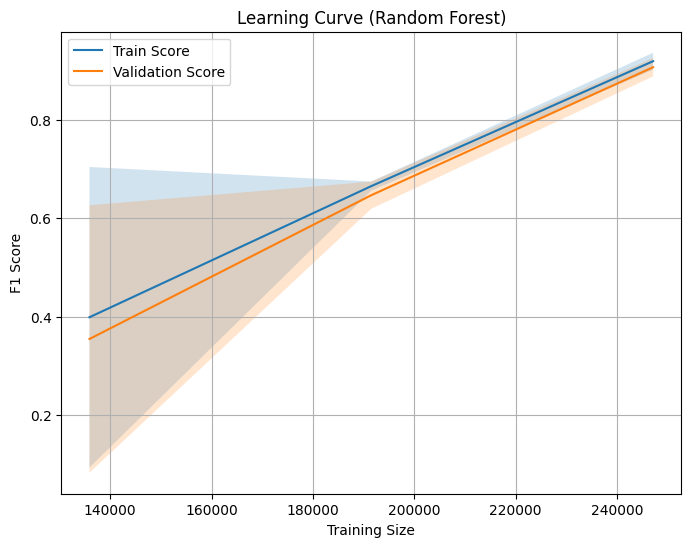

In [67]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    rf,
    X_train_res,
    y_train_res,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)
plt.figure(figsize=(8,6))

plt.plot(train_sizes, train_mean, label='Train Score')
plt.plot(train_sizes, val_mean, label='Validation Score')

# optional: shading
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)

plt.xlabel('Training Size')
plt.ylabel('F1 Score')
plt.title('Learning Curve (Random Forest)')
plt.legend()
plt.grid()
plt.show()

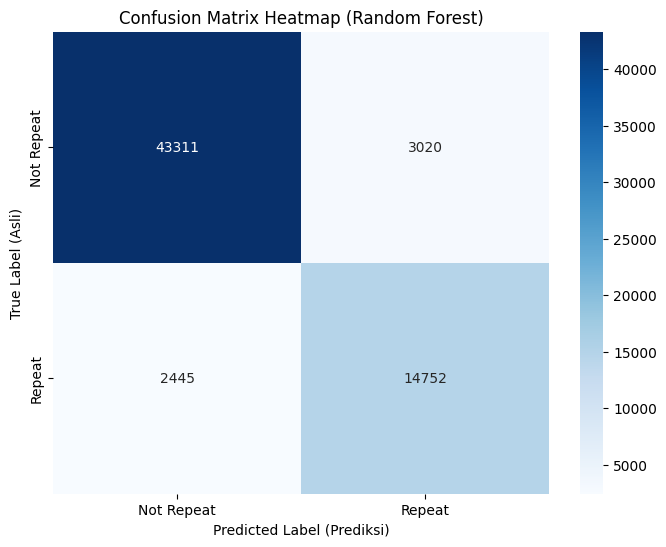

In [68]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Lakukan prediksi pada data test
y_pred = rf.predict(X_test)

# 2. Buat matriks kebingungan (confusion matrix)
cm = confusion_matrix(y_test, y_pred)

# 3. Visualisasikan dengan Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Repeat', 'Repeat'],
            yticklabels=['Not Repeat', 'Repeat'])

plt.title('Confusion Matrix Heatmap (Random Forest)')
plt.xlabel('Predicted Label (Prediksi)')
plt.ylabel('True Label (Asli)')
plt.show()

###MODEL COCOK DAN MENDAPATKAN LEARNING RATE CURVE YANG IDEAL

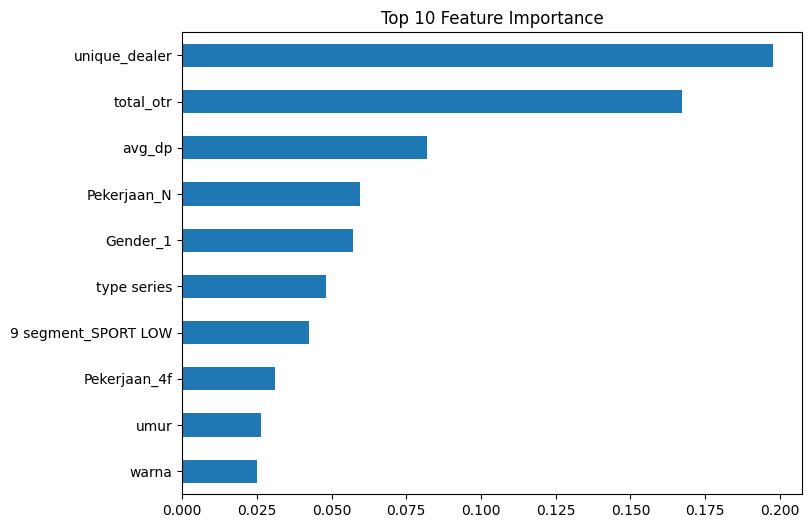

In [69]:
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = feat_importances.sort_values(ascending=False).head(10)
import matplotlib.pyplot as plt

top10.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Top 10 Feature Importance")
plt.show()

**INSIGHT**

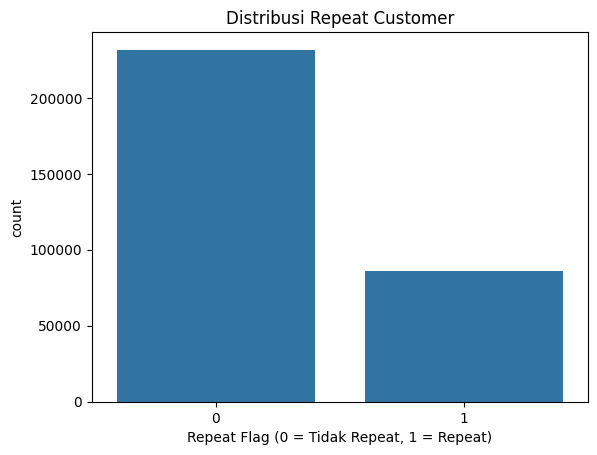

repeat_flag
0    0.729304
1    0.270696
Name: proportion, dtype: float64

In [72]:
plt.title("Distribusi Repeat Customer")
sns.countplot(x='repeat_flag', data=df_drop)
plt.xlabel("Repeat Flag (0 = Tidak Repeat, 1 = Repeat)")
plt.show()

df_drop['repeat_flag'].value_counts(normalize=True)

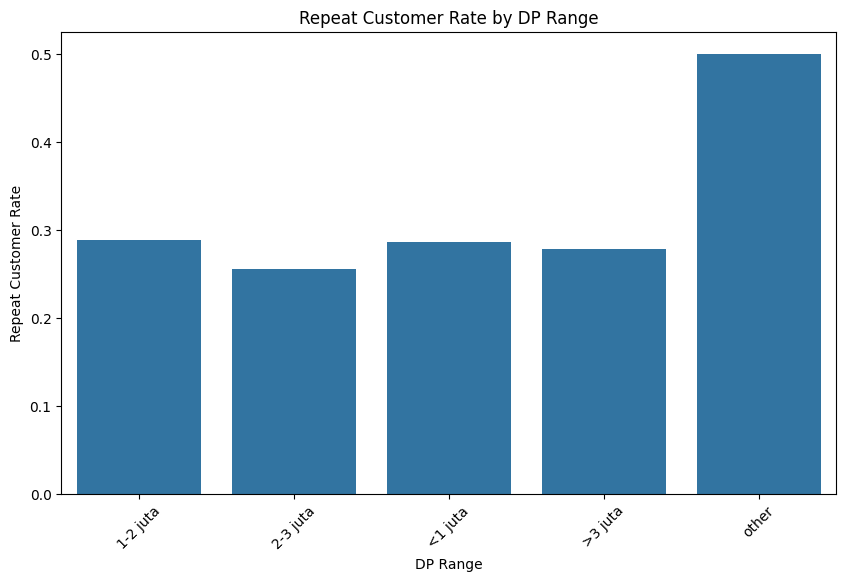

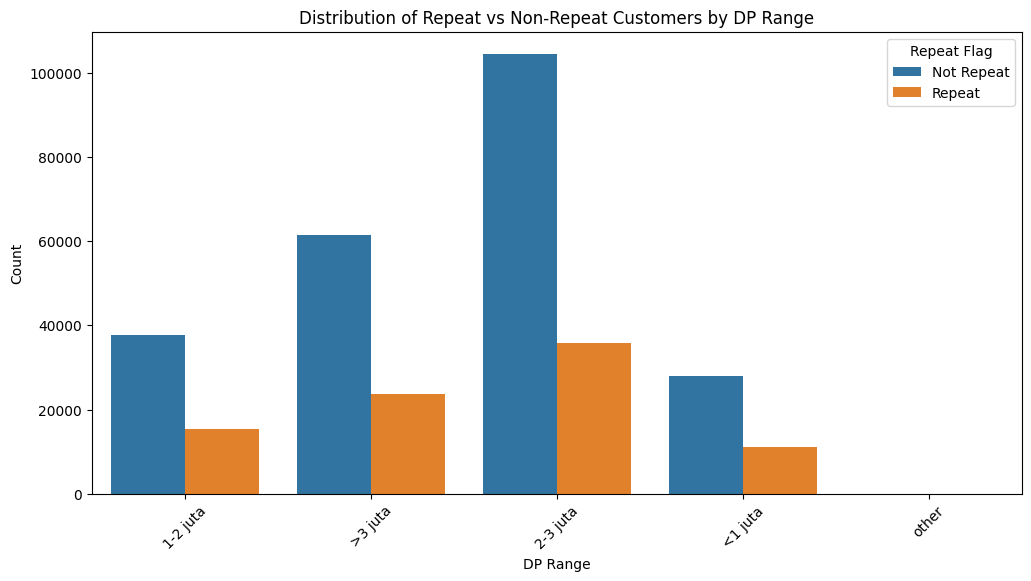

In [89]:
dp_labels = {
    0: '<1 juta',
    1: '1-2 juta',
    2: '2-3 juta',
    3: '>3 juta',
    4: 'other'
}

df_drop['range dp label'] = df_drop['range dp'].map(dp_labels)

dp_repeat = df_drop.groupby('range dp label')['repeat_flag'].mean().reset_index()
dp_repeat.columns = ['Range DP', 'Repeat Rate']

plt.figure(figsize=(10, 6))
sns.barplot(x='Range DP', y='Repeat Rate', data=dp_repeat)
plt.title('Repeat Customer Rate by DP Range')
plt.xlabel('DP Range')
plt.ylabel('Repeat Customer Rate')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='range dp label', hue='repeat_flag', data=df_drop)
plt.title('Distribution of Repeat vs Non-Repeat Customers by DP Range')
plt.xlabel('DP Range')
plt.ylabel('Count')
plt.legend(title='Repeat Flag', labels=['Not Repeat', 'Repeat'])
plt.xticks(rotation=45)
plt.show()

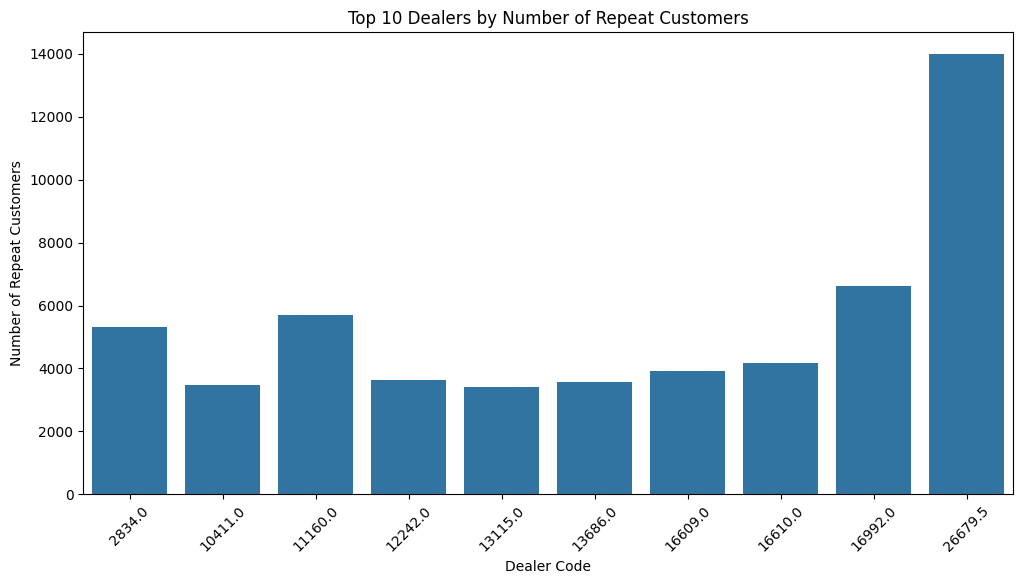

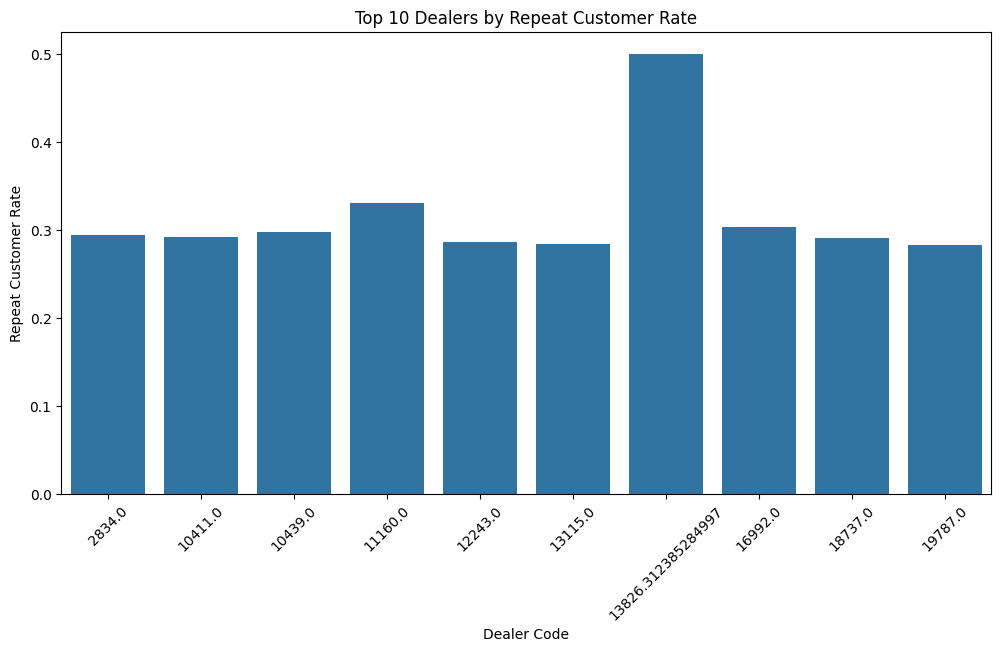

In [86]:
# Visualisasi Insight Dealer vs Repeat Flag
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah repeat customers per dealer
dealer_repeat = df_drop.groupby('Kode Dealer')['repeat_flag'].sum().reset_index()
dealer_repeat.columns = ['Kode Dealer', 'Repeat Customers']

# Ambil top 10 dealers dengan repeat customers terbanyak
top_dealers = dealer_repeat.sort_values('Repeat Customers', ascending=False).head(10)

# Plot barplot
plt.figure(figsize=(12, 6))
sns.barplot(x='Kode Dealer', y='Repeat Customers', data=top_dealers)
plt.title('Top 10 Dealers by Number of Repeat Customers')
plt.xlabel('Dealer Code')
plt.ylabel('Number of Repeat Customers')
plt.xticks(rotation=45)
plt.show()

# Alternatif: Persentase repeat rate per dealer
dealer_repeat_rate = df_drop.groupby('Kode Dealer')['repeat_flag'].mean().reset_index()
dealer_repeat_rate.columns = ['Kode Dealer', 'Repeat Rate']

# Ambil top 10 dealers dengan repeat rate tertinggi
top_dealers_rate = dealer_repeat_rate.sort_values('Repeat Rate', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='Kode Dealer', y='Repeat Rate', data=top_dealers_rate)
plt.title('Top 10 Dealers by Repeat Customer Rate')
plt.xlabel('Dealer Code')
plt.ylabel('Repeat Customer Rate')
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_6978/3323420106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='repeat_flag', y='total_otr', data=df_drop, palette='Set2')


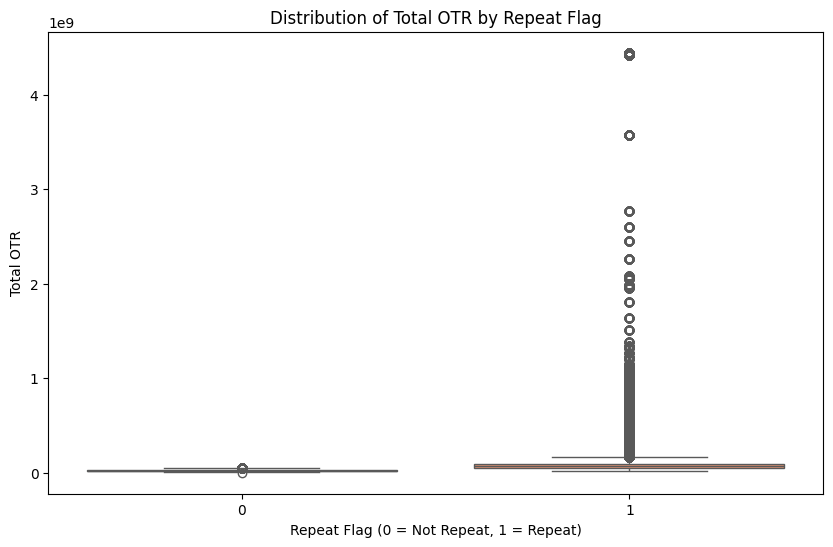

/tmp/ipykernel_6978/3323420106.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Repeat Flag', y='Average Total OTR', data=otr_repeat, palette='viridis')


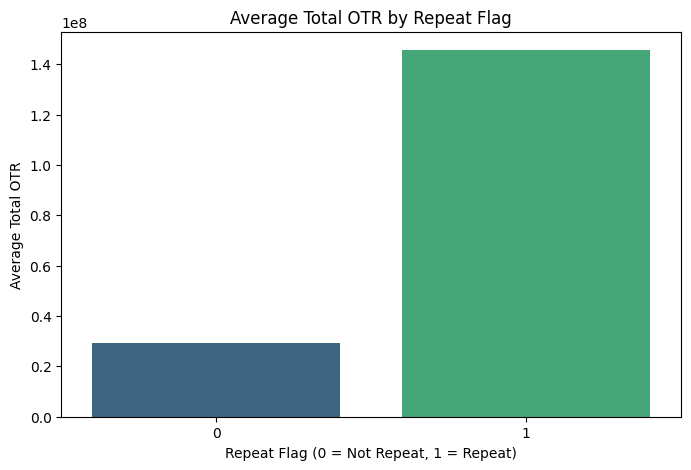

Descriptive Statistics for Total OTR by Repeat Flag:
                count          mean           std         min         25%  \
repeat_flag                                                                 
0            231654.0  2.945997e+07  1.228944e+07   1825000.0  21190000.0   
1             85983.0  1.456806e+08  3.795428e+08  23115000.0  47572500.0   

                    50%         75%           max  
repeat_flag                                        
0            23650000.0  33520000.0  5.338500e+07  
1            72095000.0  95395000.0  4.444381e+09  


In [88]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='repeat_flag', y='total_otr', data=df_drop, palette='Set2')
plt.title('Distribution of Total OTR by Repeat Flag')
plt.xlabel('Repeat Flag (0 = Not Repeat, 1 = Repeat)')
plt.ylabel('Total OTR')
plt.show()

otr_repeat = df_drop.groupby('repeat_flag')['total_otr'].mean().reset_index()
otr_repeat.columns = ['Repeat Flag', 'Average Total OTR']

plt.figure(figsize=(8, 5))
sns.barplot(x='Repeat Flag', y='Average Total OTR', data=otr_repeat, palette='viridis')
plt.title('Average Total OTR by Repeat Flag')
plt.xlabel('Repeat Flag (0 = Not Repeat, 1 = Repeat)')
plt.ylabel('Average Total OTR')
plt.show()

# Statistik deskriptif
print("Descriptive Statistics for Total OTR by Repeat Flag:")
print(df_drop.groupby('repeat_flag')['total_otr'].describe())

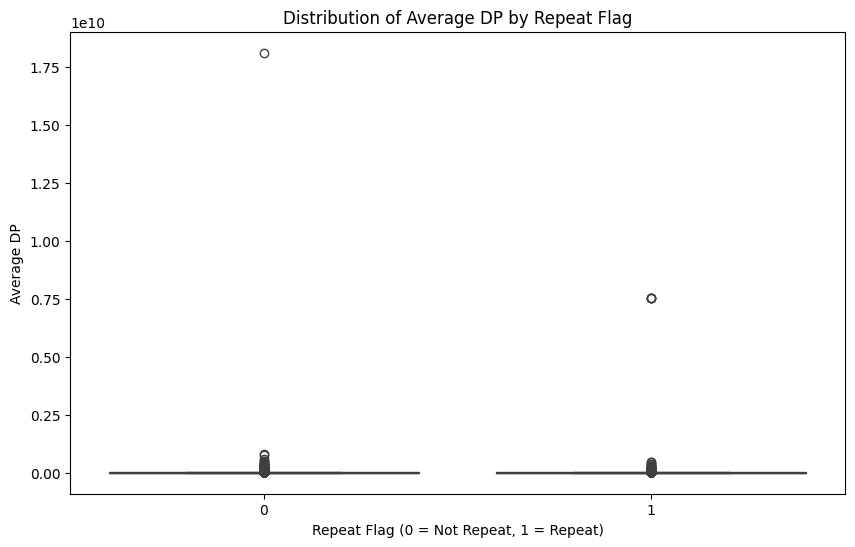

/tmp/ipykernel_6978/1416879727.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Repeat Flag', y='Average DP', data=dp_repeat_avg, palette='viridis')


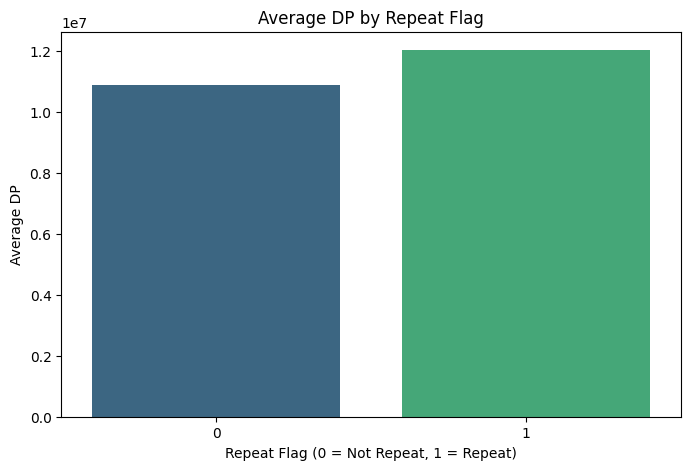

Descriptive Statistics for Average DP by Repeat Flag:
                count          mean           std  min  25%           50%  \
repeat_flag                                                                 
0            231654.0  1.090834e+07  4.478336e+07  0.0  0.0  0.000000e+00   
1             85983.0  1.204033e+07  5.419467e+07  0.0  0.0  4.166667e+06   

                      75%           max  
repeat_flag                              
0            1.000000e+07  1.810870e+10  
1            1.736667e+07  7.525500e+09  


In [91]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='repeat_flag', y='avg_dp', data=df_drop)
plt.title('Distribution of Average DP by Repeat Flag')
plt.xlabel('Repeat Flag (0 = Not Repeat, 1 = Repeat)')
plt.ylabel('Average DP')
plt.show()

dp_repeat_avg = df_drop.groupby('repeat_flag')['avg_dp'].mean().reset_index()
dp_repeat_avg.columns = ['Repeat Flag', 'Average DP']

plt.figure(figsize=(8, 5))
sns.barplot(x='Repeat Flag', y='Average DP', data=dp_repeat_avg, palette='viridis')
plt.title('Average DP by Repeat Flag')
plt.xlabel('Repeat Flag (0 = Not Repeat, 1 = Repeat)')
plt.ylabel('Average DP')
plt.show()

print("Descriptive Statistics for Average DP by Repeat Flag:")
print(df_drop.groupby('repeat_flag')['avg_dp'].describe())